# YOLO Full-Video Overlay Export

This notebook loads your YOLO model from:

```text
../models/best.pt
```

and creates a full output video with YOLO boxes overlaid on every frame.

It also supports fallback to:

```text
../models/yolo11.pt
```

The notebook saves:

```text
../outputs/yolo_overlay/overlay_video.mp4
../outputs/yolo_overlay/detections.csv
../outputs/yolo_overlay/preview_frame.jpg
```

Your `best.pt` detects both **cap** and **bottle**, so the default setting is:

```python
CLASS_NAME_FILTER = None
```

That means it will draw all classes your model detects.  
If you want only one class, for example only caps, change it later to something like:

```python
CLASS_NAME_FILTER = ["cap"]
```

## 1. Install requirements

Run once if needed:

```python
%pip install ultralytics opencv-python pandas matplotlib tqdm
```

In [7]:
from pathlib import Path
from collections import defaultdict, deque
import time
import json
import math

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

try:
    from ultralytics import YOLO
except ImportError as exc:
    raise ImportError(
        "Ultralytics is not installed. Run: %pip install ultralytics"
    ) from exc

## 2. Configuration

Change only this part first:

```python
VIDEO_PATH = Path(...)
```

The model path is already set to `../models/best.pt`.

In [8]:
# -----------------------------
# Input paths
# -----------------------------
VIDEO_PATH = Path("../data/1.avi")   # CHANGE THIS to your video path

MODEL_DIR = Path("../models")
BEST_MODEL_PATH = MODEL_DIR / "best.pt"
YOLO11_MODEL_PATH = MODEL_DIR / "yolo11n.pt"

# -----------------------------
# Output paths
# -----------------------------
OUTPUT_DIR = Path("../outputs/yolo_overlay")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_VIDEO_PATH = OUTPUT_DIR / "overlay_video.mp4"
OUTPUT_CSV_PATH = OUTPUT_DIR / "detections.csv"
OUTPUT_PREVIEW_PATH = OUTPUT_DIR / "preview_frame.jpg"

# -----------------------------
# YOLO settings
# -----------------------------
USE_TRACKING = True             # True = use model.track(...), False = use model.predict(...)
TRACKER = "bytetrack.yaml"      # "bytetrack.yaml" or "botsort.yaml"

CONF_THRESHOLD = 0.50
IOU_THRESHOLD = 0.50
IMAGE_SIZE = 640

# Use None to draw all classes detected by your best.pt model.
# Example filters:
# CLASS_NAME_FILTER = ["cap"]
# CLASS_NAME_FILTER = ["bottle"]
# CLASS_NAME_FILTER = ["cap", "bottle"]
CLASS_NAME_FILTER = None

# Optional: force CPU/GPU.
# Examples:
# DEVICE = "cpu"
# DEVICE = 0
DEVICE = None

# -----------------------------
# Drawing settings
# -----------------------------
DRAW_BOXES = True
DRAW_CENTERS = True
DRAW_LABELS = True
DRAW_TRACK_TRAILS = True
TRAIL_LENGTH = 40

BOX_THICKNESS = 2
CENTER_RADIUS = 4
FONT_SCALE = 0.55
FONT_THICKNESS = 2

# -----------------------------
# Video processing
# -----------------------------
MAX_FRAMES = None      # None = process whole video. Example: 300 for quick testing.
SAVE_EVERY_N_FRAMES_TO_CSV = 1

print("VIDEO_PATH:", VIDEO_PATH)
print("BEST_MODEL_PATH:", BEST_MODEL_PATH)
print("YOLO11_MODEL_PATH:", YOLO11_MODEL_PATH)
print("OUTPUT_VIDEO_PATH:", OUTPUT_VIDEO_PATH)
print("OUTPUT_CSV_PATH:", OUTPUT_CSV_PATH)

VIDEO_PATH: ..\data\1.avi
BEST_MODEL_PATH: ..\models\best.pt
YOLO11_MODEL_PATH: ..\models\yolo11n.pt
OUTPUT_VIDEO_PATH: ..\outputs\yolo_overlay\overlay_video.mp4
OUTPUT_CSV_PATH: ..\outputs\yolo_overlay\detections.csv


## 3. Load model

Priority:

1. `../models/best.pt`
2. `../models/yolo11.pt`

The notebook also prints class names, so you can see whether your model uses names like `cap`, `bottle`, `bottle_cap`, etc.

In [9]:
def choose_model_path():
    if BEST_MODEL_PATH.exists():
        return BEST_MODEL_PATH
    if YOLO11_MODEL_PATH.exists():
        return YOLO11_MODEL_PATH

    raise FileNotFoundError(
        "No model found. Expected one of these:\n"
        f"  {BEST_MODEL_PATH}\n"
        f"  {YOLO11_MODEL_PATH}"
    )


MODEL_PATH = choose_model_path()
model = YOLO(str(MODEL_PATH))

print("Loaded model:", MODEL_PATH)
print()
print("Model class names:")
print(model.names)

Loaded model: ..\models\best.pt

Model class names:
{0: 'Bottle', 1: 'With_Cap', 2: 'Without_Cap'}


## 4. Helper functions

In [10]:
def get_video_info(video_path: Path) -> dict:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open video: {video_path}")

    info = {
        "fps": cap.get(cv2.CAP_PROP_FPS),
        "frame_count": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    }
    cap.release()

    if info["fps"] is None or info["fps"] <= 0:
        info["fps"] = 30.0

    return info


def class_filter_to_ids(model, class_name_filter):
    if class_name_filter is None:
        return None

    names = getattr(model, "names", {})
    if isinstance(class_name_filter, str):
        class_name_filter = [class_name_filter]

    requested = {str(x).lower() for x in class_name_filter}
    matched = []

    for class_id, class_name in names.items():
        if str(class_name).lower() in requested:
            matched.append(int(class_id))

    if not matched:
        print("WARNING: No class names matched CLASS_NAME_FILTER.")
        print("Requested:", class_name_filter)
        print("Available:", names)
        return []

    print("CLASS_NAME_FILTER matched class IDs:", matched)
    return matched


def make_color(class_id):
    # Deterministic BGR color for each class ID.
    rng = np.random.default_rng(int(class_id) + 12345)
    color = rng.integers(60, 255, size=3).tolist()
    return tuple(int(c) for c in color)


def draw_text_with_background(frame, text, org, font_scale=0.55, thickness=2):
    x, y = org
    font = cv2.FONT_HERSHEY_SIMPLEX
    (tw, th), baseline = cv2.getTextSize(text, font, font_scale, thickness)

    x1 = max(x, 0)
    y1 = max(y - th - baseline - 4, 0)
    x2 = min(x + tw + 4, frame.shape[1] - 1)
    y2 = min(y + baseline + 4, frame.shape[0] - 1)

    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 0), -1)
    cv2.putText(frame, text, (x + 2, y - 2), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)


def result_to_rows(result, frame_idx, time_sec, model_names):
    rows = []

    if result.boxes is None:
        return rows

    boxes = result.boxes

    for i in range(len(boxes)):
        xyxy = boxes.xyxy[i].detach().cpu().numpy().astype(float)
        x1, y1, x2, y2 = xyxy.tolist()

        conf = float(boxes.conf[i]) if boxes.conf is not None else math.nan
        class_id = int(boxes.cls[i]) if boxes.cls is not None else -1
        class_name = str(model_names.get(class_id, class_id)) if isinstance(model_names, dict) else str(class_id)

        track_id = -1
        if getattr(boxes, "id", None) is not None and boxes.id is not None:
            track_id = int(boxes.id[i])

        x_center = (x1 + x2) / 2
        y_center = (y1 + y2) / 2
        width = x2 - x1
        height = y2 - y1

        rows.append({
            "frame": int(frame_idx),
            "time_sec": float(time_sec),
            "track_id": int(track_id),
            "class_id": int(class_id),
            "class_name": class_name,
            "confidence": float(conf),
            "x_center": float(x_center),
            "y_center": float(y_center),
            "x1": float(x1),
            "y1": float(y1),
            "x2": float(x2),
            "y2": float(y2),
            "width": float(width),
            "height": float(height),
        })

    return rows


def draw_rows_on_frame(frame, rows, trails=None):
    out = frame.copy()

    for row in rows:
        class_id = int(row["class_id"])
        class_name = row["class_name"]
        conf = row["confidence"]
        track_id = int(row["track_id"])

        x1 = int(round(row["x1"]))
        y1 = int(round(row["y1"]))
        x2 = int(round(row["x2"]))
        y2 = int(round(row["y2"]))
        cx = int(round(row["x_center"]))
        cy = int(round(row["y_center"]))

        color = make_color(class_id)

        if DRAW_BOXES:
            cv2.rectangle(out, (x1, y1), (x2, y2), color, BOX_THICKNESS)

        if DRAW_CENTERS:
            cv2.circle(out, (cx, cy), CENTER_RADIUS, (0, 0, 255), -1)
            cv2.circle(out, (cx, cy), CENTER_RADIUS + 2, color, 1)

        if DRAW_LABELS:
            if track_id >= 0:
                label = f"ID {track_id} | {class_name} {conf:.2f} | ({cx},{cy})"
            else:
                label = f"{class_name} {conf:.2f} | ({cx},{cy})"

            draw_text_with_background(
                out,
                label,
                (x1, max(y1 - 5, 15)),
                font_scale=FONT_SCALE,
                thickness=FONT_THICKNESS,
            )

        if DRAW_TRACK_TRAILS and trails is not None and track_id >= 0:
            key = (class_id, track_id)
            trails[key].append((cx, cy))

            pts = list(trails[key])
            for j in range(1, len(pts)):
                cv2.line(out, pts[j - 1], pts[j], color, 2)

    return out


def show_bgr(frame, title=None, width=1000):
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    h, w = rgb.shape[:2]
    if w > width:
        scale = width / w
        rgb = cv2.resize(rgb, (int(w * scale), int(h * scale)))

    plt.figure(figsize=(12, 7))
    plt.imshow(rgb)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


def create_video_writer(output_path: Path, fps: float, width: int, height: int):
    output_path.parent.mkdir(parents=True, exist_ok=True)

    # mp4v is usually available on Windows/Linux/macOS with OpenCV.
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))

    if not writer.isOpened():
        raise RuntimeError(f"Could not create video writer: {output_path}")

    return writer

## 5. Preview one frame

This confirms:

- the video opens correctly,
- the model detects something,
- class labels look correct.

{
  "fps": 30.00003000003,
  "frame_count": 528,
  "width": 1280,
  "height": 720
}
Detections in preview frame: 0


""


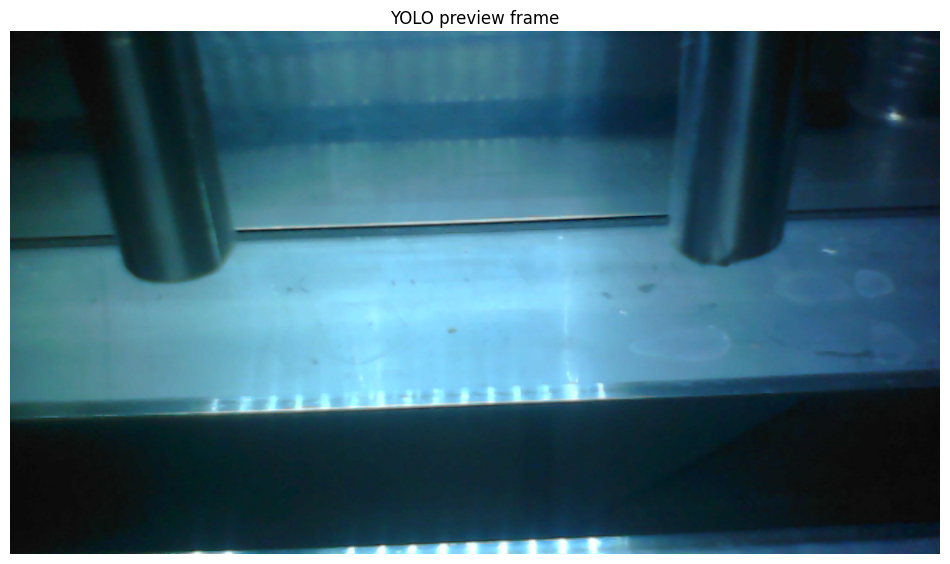

Saved preview: ..\outputs\yolo_overlay\preview_frame.jpg


In [11]:
if not VIDEO_PATH.exists():
    raise FileNotFoundError(
        f"Video not found: {VIDEO_PATH}\n"
        "Change VIDEO_PATH in the configuration cell."
    )

video_info = get_video_info(VIDEO_PATH)
print(json.dumps(video_info, indent=2))

class_ids_filter = class_filter_to_ids(model, CLASS_NAME_FILTER)

cap = cv2.VideoCapture(str(VIDEO_PATH))
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Could not read the first frame.")

infer_kwargs = {
    "conf": CONF_THRESHOLD,
    "iou": IOU_THRESHOLD,
    "imgsz": IMAGE_SIZE,
    "verbose": False,
}

if class_ids_filter is not None:
    infer_kwargs["classes"] = class_ids_filter

if DEVICE is not None:
    infer_kwargs["device"] = DEVICE

if USE_TRACKING:
    result = model.track(frame, persist=True, tracker=TRACKER, **infer_kwargs)[0]
else:
    result = model.predict(frame, **infer_kwargs)[0]

rows = result_to_rows(result, frame_idx=0, time_sec=0.0, model_names=model.names)

preview = draw_rows_on_frame(frame, rows, trails=defaultdict(lambda: deque(maxlen=TRAIL_LENGTH)))
cv2.imwrite(str(OUTPUT_PREVIEW_PATH), preview)

print(f"Detections in preview frame: {len(rows)}")
display(pd.DataFrame(rows).head(20))
show_bgr(preview, title="YOLO preview frame")
print("Saved preview:", OUTPUT_PREVIEW_PATH)

## 6. Export the whole overlaid video

This cell writes:

```text
../outputs/yolo_overlay/overlay_video.mp4
../outputs/yolo_overlay/detections.csv
```

The CSV includes both **cap** and **bottle** detections if your model outputs both.

In [12]:
def export_yolo_overlay_video(
    video_path: Path,
    output_video_path: Path,
    output_csv_path: Path,
    model,
    use_tracking: bool = True,
    max_frames=None,
):
    info = get_video_info(video_path)
    fps = info["fps"]
    width = info["width"]
    height = info["height"]
    total_frames = info["frame_count"]

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open video: {video_path}")

    writer = create_video_writer(output_video_path, fps, width, height)

    class_ids_filter = class_filter_to_ids(model, CLASS_NAME_FILTER)

    infer_kwargs = {
        "conf": CONF_THRESHOLD,
        "iou": IOU_THRESHOLD,
        "imgsz": IMAGE_SIZE,
        "verbose": False,
    }

    if class_ids_filter is not None:
        infer_kwargs["classes"] = class_ids_filter

    if DEVICE is not None:
        infer_kwargs["device"] = DEVICE

    all_rows = []
    trails = defaultdict(lambda: deque(maxlen=TRAIL_LENGTH))

    frame_idx = 0
    processed = 0
    start_time = time.perf_counter()

    pbar_total = total_frames if max_frames is None else min(total_frames, max_frames)

    with tqdm(total=pbar_total, desc="Exporting YOLO overlay video") as pbar:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            time_sec = frame_idx / fps if fps else 0.0

            if use_tracking:
                result = model.track(frame, persist=True, tracker=TRACKER, **infer_kwargs)[0]
            else:
                result = model.predict(frame, **infer_kwargs)[0]

            rows = result_to_rows(result, frame_idx, time_sec, model.names)

            if frame_idx % SAVE_EVERY_N_FRAMES_TO_CSV == 0:
                all_rows.extend(rows)

            overlay = draw_rows_on_frame(frame, rows, trails=trails)
            writer.write(overlay)

            frame_idx += 1
            processed += 1
            pbar.update(1)

            if max_frames is not None and processed >= max_frames:
                break

    cap.release()
    writer.release()

    elapsed = time.perf_counter() - start_time
    processing_fps = processed / elapsed if elapsed > 0 else 0

    df = pd.DataFrame(all_rows)
    output_csv_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_csv_path, index=False)

    summary = {
        "input_video": str(video_path),
        "output_video": str(output_video_path),
        "output_csv": str(output_csv_path),
        "model": str(MODEL_PATH),
        "use_tracking": use_tracking,
        "processed_frames": processed,
        "video_fps": fps,
        "processing_fps": processing_fps,
        "detections_saved": len(df),
        "class_filter": CLASS_NAME_FILTER,
    }

    return df, summary


detections_df, export_summary = export_yolo_overlay_video(
    video_path=VIDEO_PATH,
    output_video_path=OUTPUT_VIDEO_PATH,
    output_csv_path=OUTPUT_CSV_PATH,
    model=model,
    use_tracking=USE_TRACKING,
    max_frames=MAX_FRAMES,
)

print(json.dumps(export_summary, indent=2))
display(detections_df.head(20))
print("Saved video:", OUTPUT_VIDEO_PATH)
print("Saved CSV:", OUTPUT_CSV_PATH)

Exporting YOLO overlay video:   0%|          | 0/528 [00:00<?, ?it/s]

{
  "input_video": "..\\data\\1.avi",
  "output_video": "..\\outputs\\yolo_overlay\\overlay_video.mp4",
  "output_csv": "..\\outputs\\yolo_overlay\\detections.csv",
  "model": "..\\models\\best.pt",
  "use_tracking": true,
  "processed_frames": 528,
  "video_fps": 30.00003000003,
  "processing_fps": 6.833465281551379,
  "detections_saved": 289,
  "class_filter": null
}


,frame,time_sec,track_id,class_id,class_name,confidence,x_center,y_center,x1,y1,x2,y2,width,height
0,57,1.899998,-1,2,Without_Cap,0.773098,1193.668213,548.968628,1107.404297,393.996094,1279.932129,703.941162,172.527832,309.945068
1,59,1.966665,-1,2,Without_Cap,0.554076,1118.200195,512.401733,957.899292,304.803467,1278.501099,720.000000,320.601807,415.196533
2,60,1.999998,2,2,Without_Cap,0.831040,1084.920898,521.740936,939.899780,334.742920,1229.942017,708.738953,290.042236,373.996033
3,62,2.066665,-1,2,Without_Cap,0.798716,880.411255,527.187561,698.877930,337.707214,1061.944580,716.667908,363.066650,378.960693
4,63,2.099998,3,2,Without_Cap,0.824735,803.549927,505.811432,603.823364,297.102478,1003.276489,714.520386,399.453125,417.417908
5,64,2.133331,3,2,Without_Cap,0.824985,695.949326,507.418198,497.582245,299.660675,894.316406,715.175720,396.734161,415.515045
6,65,2.166664,3,2,Without_Cap,0.587578,566.687027,503.803436,365.812592,292.627319,767.561462,714.979553,401.748871,422.352234
7,66,2.199998,2,2,Without_Cap,0.614846,1078.075653,522.322250,930.511169,336.954498,1225.640137,707.690002,295.128967,370.735504
8,68,2.266664,3,2,Without_Cap,0.842357,216.795242,537.449921,51.455383,366.401062,382.135101,708.498779,330.679718,342.097717
9,69,2.299998,5,2,Without_Cap,0.778602,779.824646,512.452805,596.293762,306.487885,963.355530,718.417725,367.061768,411.929840


Saved video: ..\outputs\yolo_overlay\overlay_video.mp4
Saved CSV: ..\outputs\yolo_overlay\detections.csv


## 7. Check class counts

This helps confirm how many `cap` and `bottle` detections were saved.

In [13]:
if not detections_df.empty:
    display(
        detections_df
        .groupby("class_name")
        .agg(
            count=("class_name", "size"),
            mean_confidence=("confidence", "mean"),
            mean_width=("width", "mean"),
            mean_height=("height", "mean"),
        )
        .sort_values("count", ascending=False)
    )
else:
    print("No detections were saved.")

,count,mean_confidence,mean_width,mean_height
class_name,,,,
Without_Cap,287,0.807206,328.644262,389.098202
Bottle,2,0.504351,149.272522,325.096176


## 8. Optional: save separate CSV files for cap and bottle

Change the class names if your model uses different names.

In [14]:
CAP_CLASS_NAMES = ["cap", "bottle_cap", "bottle mouth", "bottle_mouth"]
BOTTLE_CLASS_NAMES = ["bottle"]

def save_class_subset(df, class_names, output_path):
    if df.empty:
        print("No detections to filter.")
        return pd.DataFrame()

    wanted = {name.lower() for name in class_names}
    subset = df[df["class_name"].str.lower().isin(wanted)].copy()
    subset.to_csv(output_path, index=False)
    print(f"Saved {len(subset)} rows to {output_path}")
    return subset


cap_df = save_class_subset(
    detections_df,
    CAP_CLASS_NAMES,
    OUTPUT_DIR / "cap_detections.csv"
)

bottle_df = save_class_subset(
    detections_df,
    BOTTLE_CLASS_NAMES,
    OUTPUT_DIR / "bottle_detections.csv"
)

display(cap_df.head())
display(bottle_df.head())

Saved 0 rows to ..\outputs\yolo_overlay\cap_detections.csv
Saved 2 rows to ..\outputs\yolo_overlay\bottle_detections.csv


,frame,time_sec,track_id,class_id,class_name,confidence,x_center,y_center,x1,y1,x2,y2,width,height


,frame,time_sec,track_id,class_id,class_name,confidence,x_center,y_center,x1,y1,x2,y2,width,height
111,190,6.333327,-1,0,Bottle,0.504936,992.933350,163.534134,920.916992,1.058044,1064.949707,326.010223,144.032715,324.952179
207,338,11.266655,-1,0,Bottle,0.503766,993.707092,162.620087,916.450928,0.000000,1070.963257,325.240173,154.512329,325.240173


## 9. Optional: create a cap-center-only video

If your model detects both `cap` and `bottle`, but you want a second video showing only cap detections, set:

```python
CLASS_NAME_FILTER = ["cap"]
```

then rerun from section 5 or 6.

If your class is not named `cap`, check `model.names` in section 3 and use the exact class name.

# Notes

- `USE_TRACKING = True` gives persistent object IDs when possible.
- `USE_TRACKING = False` only draws per-frame detections.
- `CLASS_NAME_FILTER = None` keeps all detections from `best.pt`.
- For cap/head pixel locations, use `x_center`, `y_center` from `cap_detections.csv`.
- For whole-bottle pixel locations, use `x_center`, `y_center` from `bottle_detections.csv`.